# Sistema anti spoofing
# Felipe Meier Martins | 22100504

Esse notebook tem como objetivo desenvolver, através de técnicas de processamento de imagem, um sistema antifraudes para aplicações de reconhecimento facial. Foi coletado um dataset de fotos de pessoas reais e fotos dessas pessoas tiradas a partir de um celular (fraudes).

Assim, foram utilizadas duas técnicas para extrair features das imagens, o laplaciano e o método Local Binary Paterns (LBP). Após gerar as features foi feito um benchmarking com classificadores clássicos de aprendizado superviosionado como regressão logística, SVM, randomforest e gradient boosting.

Ao final, o classificador com melhor desenpenho na validação k-fold foi utilizado no conjunto de teste, tirando os resultados desse trabalho.

# Pré processamento dos dados

In [1]:
def plots(history, xlim=None, ylim=None):
  if hasattr(history, 'history'):
    history = history.history
  plt.figure(figsize=(14, 4))
  plt.subplot(1, 2, 1)
  plt.plot(history['loss'], '.-', label='Train loss')
    
  if 'val_loss' in history.keys():
    plt.plot(history['val_loss'], '.-', label='Val loss')
  plt.xlabel('Epochs');
  plt.legend();
  plt.yscale('log')
  plt.grid(which='both');
  metrics = [m for m in history.keys() if not (m == 'loss' or m.startswith('val_') or m.startswith('Unnamed'))]
  if len(metrics) == 0: return
  plt.subplot(1, 2, 2)
  plt.plot(history[metrics[0]], '.-', label='Train ' + metrics[0])
  plt.xlabel('Epochs');
  if 'val_' + metrics[0] in history.keys():
    v = list(history['val_' + metrics[0]])
    plt.plot(v, '.-', label='Val ' + metrics[0])
    plt.title(f"Val {metrics[0]}: {max(v):.1%} (max) | {v[-1]:.1%} (last)");
  plt.legend();
  plt.xlim(xlim);
  plt.ylim(ylim);
  plt.grid();

In [2]:
import os
import pandas as pd

def coletar_imagens_com_rotulo(caminho_base, rotulo):
    caminhos = []
    rotulos = []

    for raiz, dirs, arquivos in os.walk(caminho_base):
        for nome_arquivo in arquivos:
            if nome_arquivo.lower().endswith(('.jpg', '.jpeg', '.png')):
                caminhos.append(os.path.join(raiz, nome_arquivo))
                rotulos.append(rotulo)

    return caminhos, rotulos

In [3]:
caminho_reais = "/kaggle/input/fotos-treinamento"
caminho_spoofing = "/kaggle/input/spoofing-faces"

# Coleta das imagens
caminhos_reais, rotulos_reais = coletar_imagens_com_rotulo(caminho_reais, 1)
caminhos_spoofing, rotulos_spoofing = coletar_imagens_com_rotulo(caminho_spoofing, 0)

# Unifica os dados
caminhos = caminhos_reais + caminhos_spoofing
rotulos = rotulos_reais + rotulos_spoofing

# Cria um DataFrame 
df = pd.DataFrame({'caminho_imagem': caminhos, 'rotulo': rotulos})


print(f"Total de imagens: {len(df)}")
display(df.head())

Total de imagens: 800


,caminho_imagem,rotulo
0,/kaggle/input/fotos-treinamento/GUF_NOITE/foto...,1
1,/kaggle/input/fotos-treinamento/GUF_NOITE/foto...,1
2,/kaggle/input/fotos-treinamento/GUF_NOITE/foto...,1
3,/kaggle/input/fotos-treinamento/GUF_NOITE/foto...,1
4,/kaggle/input/fotos-treinamento/GUF_NOITE/foto...,1


### Passando as imagens pelo detector de faces (Haarcascade): https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html 

In [4]:
import cv2
from tqdm import tqdm
# Carrega o classificador Haar Cascade do OpenCV
haar_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haar_path)

# Listas para armazenar os rostos e rótulos finais
imagens_faces = []
rotulos_faces = []

for caminho, rotulo in tqdm(zip(caminhos, rotulos), total=len(caminhos), desc="Processando imagens"):
    img = cv2.imread(caminho)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) > 0:
        # Assume a primeira face detectada
        (x, y, w, h) = faces[0]
        face_crop = img[y:y+h, x:x+w]
        imagens_faces.append(face_crop)
        rotulos_faces.append(rotulo)
    # Caso contrário, a imagem é descartada

# Cria o DataFrame final
df_faces = pd.DataFrame({
    'imagem': imagens_faces,
    'rotulo': rotulos_faces
})

print(f"Total de imagens com face detectada: {len(df_faces)}")
display(df_faces)

Processando imagens: 100%|██████████| 800/800 [01:26<00:00,  9.26it/s]


Total de imagens com face detectada: 698


,imagem,rotulo
0,"[[[104, 107, 111], [95, 100, 103], [95, 100, 1...",1
1,"[[[108, 111, 116], [114, 115, 119], [109, 112,...",1
2,"[[[146, 170, 170], [149, 171, 169], [139, 162,...",1
3,"[[[66, 70, 71], [56, 60, 61], [69, 71, 72], [8...",1
4,"[[[101, 104, 109], [98, 98, 104], [91, 91, 97]...",1
...,...,...
693,"[[[117, 103, 109], [116, 102, 108], [117, 103,...",0
694,"[[[122, 107, 121], [120, 107, 121], [121, 108,...",0
695,"[[[104, 103, 113], [102, 101, 111], [101, 99, ...",0
696,"[[[109, 97, 103], [108, 98, 104], [108, 97, 10...",0


In [5]:
len(imagens_faces)

698

In [6]:
contagem = df_faces['rotulo'].value_counts()

print(f"Imagens reais (rótulo 1): {contagem.get(1, 0)}")
print(f"Imagens spoofing (rótulo 0): {contagem.get(0, 0)}")


Imagens reais (rótulo 1): 375
Imagens spoofing (rótulo 0): 323


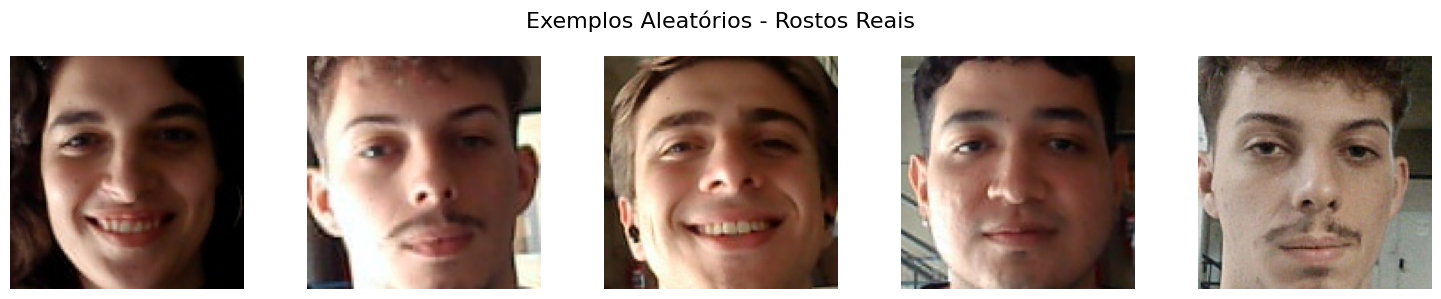

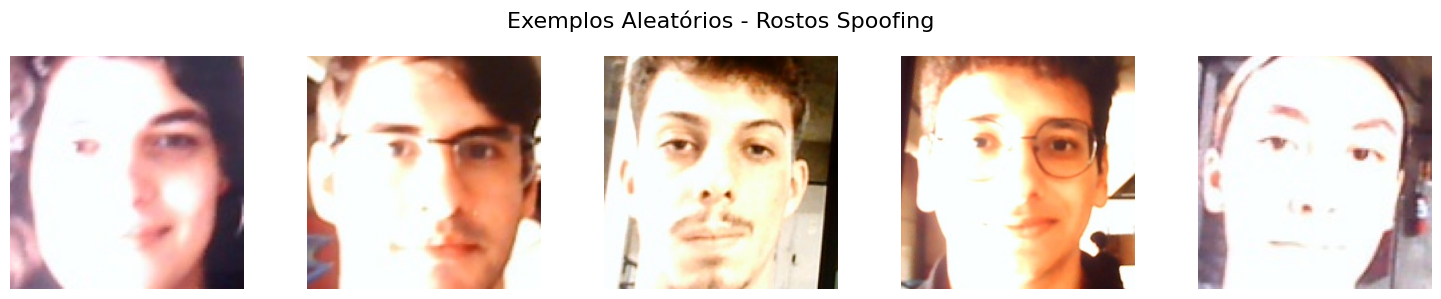

In [7]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def plotar_exemplos_listas(imagens, rotulos, rotulo_desejado, qtd=5, titulo=''):
    # Filtra índices das imagens com o rótulo desejado
    indices = [i for i, r in enumerate(rotulos) if r == rotulo_desejado]
    
    # Se quiser, pega uma amostra aleatória dos índices filtrados
    np.random.seed(42)
    if len(indices) < qtd:
        qtd = len(indices)
    amostra_idx = np.random.choice(indices, qtd, replace=False)
    
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(amostra_idx):
        img = imagens[idx]
        plt.subplot(1, qtd, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
    plt.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

plotar_exemplos_listas(imagens_faces, rotulos_faces, rotulo_desejado=1, qtd=5, titulo='Exemplos Aleatórios - Rostos Reais')
plotar_exemplos_listas(imagens_faces, rotulos_faces, rotulo_desejado=0, qtd=5, titulo='Exemplos Aleatórios - Rostos Spoofing')


In [8]:
from sklearn.model_selection import train_test_split

# Primeiro, separa treino (70%) e o restante (30%)
df_treino, df_temp = train_test_split(
    df_faces,
    test_size=0.3,
    stratify=df_faces['rotulo'],
    random_state=42
)

# Agora separa df_temp em validação e teste (50%/50% do restante = 15% cada)
df_validacao, df_teste = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp['rotulo'],
    random_state=42
)

# Verifica tamanhos e proporções
print("Treino:", len(df_treino), "Reais:", sum(df_treino['rotulo'] == 1), "Spoofing:", sum(df_treino['rotulo'] == 0))
print("Validação:", len(df_validacao), "Reais:", sum(df_validacao['rotulo'] == 1), "Spoofing:", sum(df_validacao['rotulo'] == 0))
print("Teste:", len(df_teste), "Reais:", sum(df_teste['rotulo'] == 1), "Spoofing:", sum(df_teste['rotulo'] == 0))


Treino: 488 Reais: 262 Spoofing: 226
Validação: 105 Reais: 57 Spoofing: 48
Teste: 105 Reais: 56 Spoofing: 49


### Gerar features de imagem a partir do Laplaciano

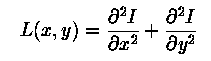

### Passando para grayscale

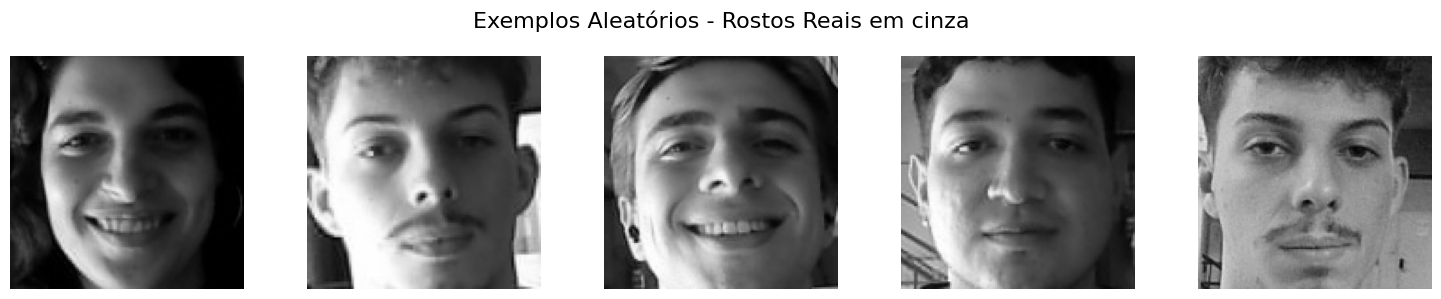

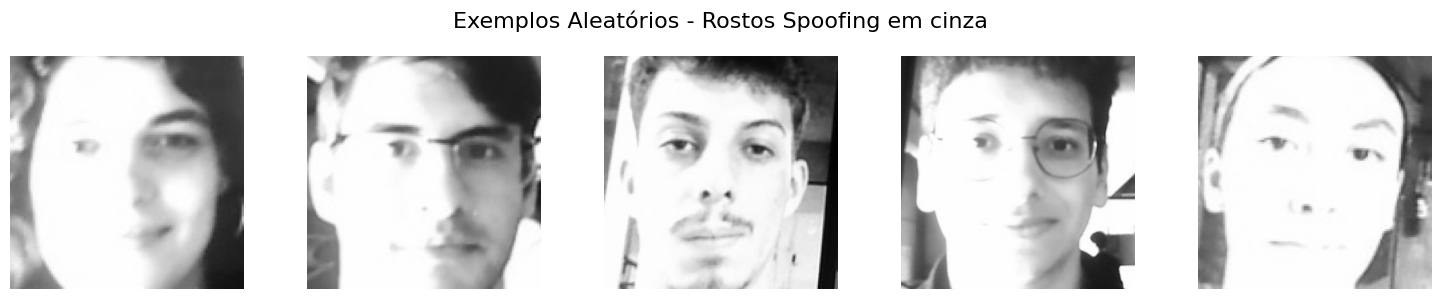

In [9]:
imagens_faces_gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in imagens_faces]
plotar_exemplos_listas(imagens_faces_gray, rotulos_faces, rotulo_desejado=1, qtd=5, titulo='Exemplos Aleatórios - Rostos Reais em cinza')
plotar_exemplos_listas(imagens_faces_gray, rotulos_faces, rotulo_desejado=0, qtd=5, titulo='Exemplos Aleatórios - Rostos Spoofing em cinza')

Passando por um filtro de suavização para reduzir ruídos antes de aplicar o laplaceano

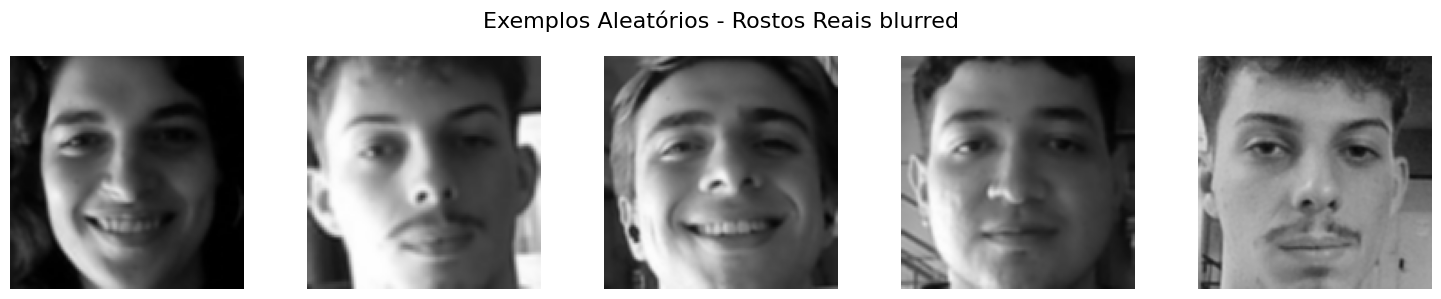

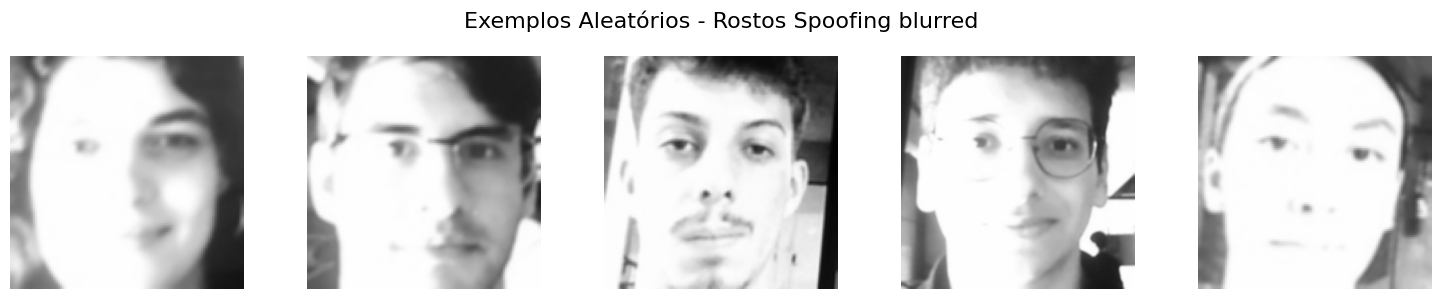

In [10]:
imagens_blurred = [cv2.GaussianBlur(img, (3,3), 0) for img in imagens_faces_gray]
plotar_exemplos_listas(imagens_blurred, rotulos_faces, rotulo_desejado=1, qtd=5, titulo='Exemplos Aleatórios - Rostos Reais blurred')
plotar_exemplos_listas(imagens_blurred, rotulos_faces, rotulo_desejado=0, qtd=5, titulo='Exemplos Aleatórios - Rostos Spoofing blurred')

### Aplicando o laplaciano

In [11]:
def plot_laplacian_images(imagens_lap, rotulos, rotulo_desejado, qtd=5, titulo=''):
    indices = [i for i, r in enumerate(rotulos) if r == rotulo_desejado]
    np.random.seed(20)
    if len(indices) < qtd:
        qtd = len(indices)
    amostra_idx = np.random.choice(indices, qtd, replace=False)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(amostra_idx):
        img = imagens_lap[idx]
        # Normalizar para 0-255 e converter para uint8 para visualização
        img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        img_uint8 = img_norm.astype(np.uint8)
        plt.subplot(1, qtd, i + 1)
        plt.imshow(img_uint8, cmap='gray')  # escala de cinza
        plt.axis('off')
    plt.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

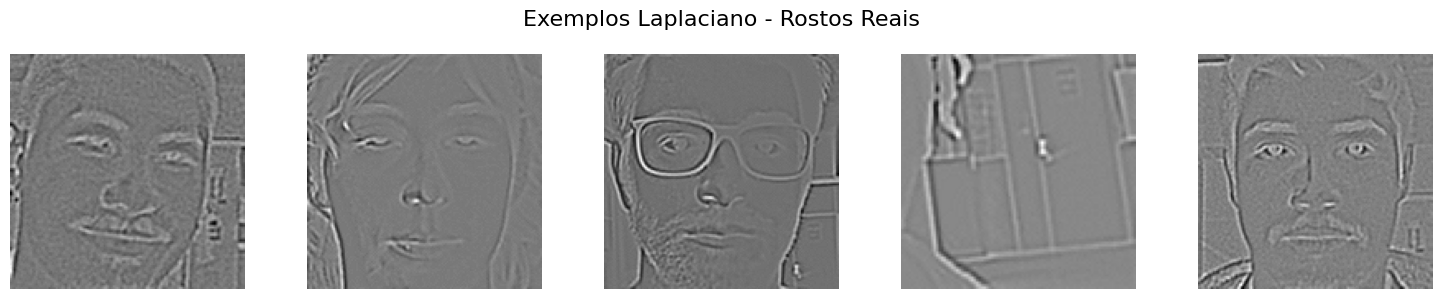

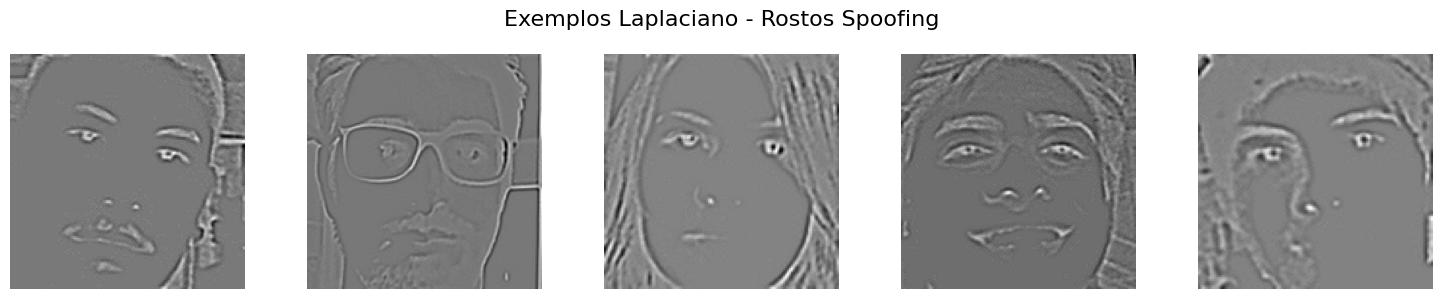

In [12]:
laplacian = [cv2.Laplacian(img, cv2.CV_64F) for img in imagens_blurred]
plot_laplacian_images(laplacian, rotulos_faces, rotulo_desejado=1, qtd=5, titulo='Exemplos Laplaciano - Rostos Reais')
plot_laplacian_images(laplacian, rotulos_faces, rotulo_desejado=0, qtd=5, titulo='Exemplos Laplaciano - Rostos Spoofing')

# Extrair features a partir do laplaciano

In [13]:
def extrair_features_laplaciano(img_lap, num_bins=10, limiar=20):
    # Usa valores absolutos para capturar magnitude das bordas
    lap_abs = np.abs(img_lap)

    mean_val = lap_abs.mean()
    std_val = lap_abs.std()
    max_val = lap_abs.max()
    min_val = lap_abs.min()

    # Histograma normalizado dos valores absolutos
    hist, bin_edges = np.histogram(lap_abs, bins=num_bins, range=(0, lap_abs.max()), density=True)

    # Monta vetor final de features concatenando tudo
    features = np.hstack([mean_val, std_val, max_val, min_val, hist])

    return features

In [14]:
features_array = np.array([extrair_features_laplaciano(img) for img in laplacian])

In [15]:
np.shape(features_array)

(698, 14)

# Dividindo conjuntos em treino e teste

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_array, rotulos_faces, 
    test_size=0.2, 
    stratify=rotulos_faces, 
    random_state=42
)


print(f'Treino: {len(X_train)}, Teste: {len(X_test)}')


Treino: 558, Teste: 140


# Laplaciano - Regressão Logística

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_score


Treinando com parâmetros padrão

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

print("Acurácias Balanceadas para cada fold:", cv_scores)

Acurácias Balanceadas para cada fold: [0.84807692 0.90192308 0.91730769 0.92598039 0.85490196]


In [19]:
print(f'Acurácia balanceada média: {100*cv_scores.mean()}%')

Acurácia balanceada média: 88.96380090497736%


Otimizando hiperparâmetros

In [20]:
from sklearn.preprocessing import StandardScaler

# Criar pipeline com normalização + modelo
preprocess_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)
param_grid = {
    'logisticregression__C': 10.0**np.arange(-2, 3.01, 1),  # Parâmetro de regularização
    'logisticregression__solver': ['liblinear', 'lbfgs'],  # Algoritmos de otimização
    'logisticregression__max_iter': [100, 500, 1000],  # Número de iterações
}

# Instanciando o GridSearchCV
grid_search = GridSearchCV(estimator=preprocess_pipeline, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='balanced_accuracy')

In [21]:
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = results[[
    'param_logisticregression__C',
    'param_logisticregression__solver',
    'param_logisticregression__max_iter',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

tabela_resultados.columns = ['C', 'Solver', 'Max Iter', 'Balanced Accuracy', 'Rank']

display(tabela_resultados.head(8))

,C,Solver,Max Iter,Balanced Accuracy,Rank
26,100.0,liblinear,500,0.932828,1
24,100.0,liblinear,100,0.932828,1
25,100.0,lbfgs,100,0.932828,1
29,100.0,lbfgs,1000,0.932828,1
28,100.0,liblinear,1000,0.932828,1
27,100.0,lbfgs,500,0.932828,1
20,10.0,liblinear,500,0.930905,7
22,10.0,liblinear,1000,0.930905,7


# Laplaciano - SVM

In [22]:
from sklearn.svm import SVC
model = SVC(kernel='rbf')  # Kernel RBF já fixado
preprocess_pipeline = make_pipeline(StandardScaler(),
 model)

param_grid = {
    'svc__C': 10.0**np.arange(-0.5, 1, 0.25),  
    'svc__gamma': 10.0**np.arange(-1, 0, 0.2),  
    'svc__max_iter': [1000, 1500, 2000]  
}

grid_search = GridSearchCV(estimator=preprocess_pipeline, 
                           param_grid=param_grid,
                           cv=5, 
                           n_jobs=-1,
                           scoring='balanced_accuracy')

Treinando com os parâmetros padrão

In [23]:
from sklearn.model_selection import cross_val_score
model = preprocess_pipeline
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

print("Acurácias Balanceadas para cada fold:", cv_scores)

Acurácias Balanceadas para cada fold: [0.86474359 0.94358974 0.92820513 0.90490196 0.87696078]


In [24]:
print(f"Acurácias Balanceadas média:{100*cv_scores.mean()}%")

Acurácias Balanceadas média:90.36802413273001%


Otimizando hiperparâmetros

In [25]:
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = results[[
    'param_svc__C',
    'param_svc__gamma',
    'param_svc__max_iter',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

tabela_resultados.columns = ['C', 'Gamma', 'Max Iter', 'Balanced Accuracy', 'Rank']

tabela_resultados['Balanced Accuracy'] = tabela_resultados['Balanced Accuracy'].round(4)

display(tabela_resultados)

,C,Gamma,Max Iter,Balanced Accuracy,Rank
83,5.623413,0.251189,2000,0.9689,1
82,5.623413,0.251189,1500,0.9689,1
81,5.623413,0.251189,1000,0.9689,1
78,5.623413,0.158489,1000,0.9611,4
80,5.623413,0.158489,2000,0.9611,4
...,...,...,...,...,...
14,0.316228,0.630957,2000,0.8665,85
13,0.316228,0.630957,1500,0.8665,85
2,0.316228,0.1,2000,0.8643,88
1,0.316228,0.1,1500,0.8643,88


# Laplaciano - RandomForest

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=0)  
preprocess_pipeline = make_pipeline(StandardScaler(),
 model)
param_grid = {#treinei diversas vezes com multiplos hiperparâmetros, e fui pegando os melhores, por isso estou treinando as vezes com uma opção apenas para ganhar tempo
    'randomforestclassifier__n_estimators': [20, 50],    # número de árvores
    'randomforestclassifier__max_depth': [400, 1000],  # profundidade
    'randomforestclassifier__min_samples_split': [2, 5, 10],  # split mínimo
    'randomforestclassifier__min_samples_leaf': [2, 5, 10],
    'randomforestclassifier__bootstrap': [True]
}
grid_search = GridSearchCV(preprocess_pipeline, param_grid, cv=5, n_jobs=-1, scoring='balanced_accuracy')

Treinando com valores padrão

In [27]:
from sklearn.model_selection import cross_val_score
model = preprocess_pipeline
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

print("Acurácias Balanceadas para cada fold:", cv_scores)

Acurácias Balanceadas para cada fold: [0.91025641 0.86602564 0.93653846 0.88823529 0.88970588]


In [28]:
print(f"Acurácias Balanceadas média:{100*cv_scores.mean()}%")

Acurácias Balanceadas média:89.81523378582203%


Otimizando hiperparâmetros

In [29]:
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = results[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'param_randomforestclassifier__min_samples_split',
    'param_randomforestclassifier__min_samples_leaf',
    'param_randomforestclassifier__bootstrap',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

tabela_resultados.columns = ['randomforestclassifier__n_estimators', 'randomforestclassifier__max_depth', 'randomforestclassifier__min_samples_split', 'randomforestclassifier__min_samples_leaf','randomforestclassifier__bootstrap','Balanced Accuracy', 'Rank']

tabela_resultados['Balanced Accuracy'] = tabela_resultados['Balanced Accuracy'].round(4)

display(tabela_resultados.head(8))

,randomforestclassifier__n_estimators,randomforestclassifier__max_depth,randomforestclassifier__min_samples_split,randomforestclassifier__min_samples_leaf,randomforestclassifier__bootstrap,Balanced Accuracy,Rank
2,20,400,5,2,True,0.8921,1
20,20,1000,5,2,True,0.8921,1
4,20,400,10,2,True,0.8870,3
22,20,1000,10,2,True,0.8870,3
5,50,400,10,2,True,0.8865,5
23,50,1000,10,2,True,0.8865,5
1,50,400,2,2,True,0.8862,7
19,50,1000,2,2,True,0.8862,7


# Laplaciano - Gradient boosting 

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=0)  
preprocess_pipeline = make_pipeline(StandardScaler(),
 model)
param_grid = {
    'gradientboostingclassifier__n_estimators': [200, 300],  # Número de árvores
    'gradientboostingclassifier__learning_rate': [0.7, 1, 1.2],  # Taxa de aprendizado
    'gradientboostingclassifier__max_depth': [3, 5, 7],  # Profundidade das árvores
}

grid_search = GridSearchCV(estimator=preprocess_pipeline, 
                           param_grid=param_grid,
                           cv=5, 
                           n_jobs=-1, 
                           scoring='balanced_accuracy')

Treinando com valores padrão

In [31]:
from sklearn.model_selection import cross_val_score
model = preprocess_pipeline
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

print("Acurácias Balanceadas para cada fold:", cv_scores)

Acurácias Balanceadas para cada fold: [0.9224359  0.88269231 0.93525641 0.89509804 0.90098039]


In [32]:
print(f"Acurácia Balanceada média:{100*cv_scores.mean()}%")

Acurácia Balanceada média:90.7292609351433%


Otimizando hiperparâmetros

In [33]:
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = results[[
    'param_gradientboostingclassifier__n_estimators',
    'param_gradientboostingclassifier__learning_rate',
    'param_gradientboostingclassifier__max_depth',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

tabela_resultados.columns = ['gradientboostingclassifier__n_estimators', 'gradientboostingclassifier__learning_rate', 'gradientboostingclassifier__max_depth', 'Balanced Accuracy', 'Rank']

tabela_resultados['Balanced Accuracy'] = tabela_resultados['Balanced Accuracy'].round(4)

display(tabela_resultados.head(8))

,gradientboostingclassifier__n_estimators,gradientboostingclassifier__learning_rate,gradientboostingclassifier__max_depth,Balanced Accuracy,Rank
8,200,1,5,0.9278,1
9,300,1,5,0.9278,1
13,300,1.2,3,0.9264,3
12,200,1.2,3,0.9264,3
7,300,1,3,0.9234,5
6,200,1,3,0.9234,5
0,200,0.7,3,0.9225,7
1,300,0.7,3,0.9225,7


# Conjunto de teste: O melhor desempenho foi do SVM, farei os testes com esse modelo

In [34]:
model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf',
        C=0.562341,
        gamma=0.251189,
        max_iter=2000, 
        random_state=0  
    )
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=0.562341, gamma=0.251189, max_iter=2000,
                     random_state=0))])

In [35]:
y_train_pred = model.predict(X_train)
train_balanced_acc = balanced_accuracy_score(y_train, y_train_pred)

# Prediz no conjunto de teste
y_test_pred = model.predict(X_test)
test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

# Exibe os resultados
print(f"Acurácia balanceada no conjunto de treino: {train_balanced_acc:.4f}")
print(f"Acurácia balanceada no conjunto de teste: {test_balanced_acc:.4f}")

Acurácia balanceada no conjunto de treino: 0.9313
Acurácia balanceada no conjunto de teste: 0.9385


# Local Binary patterns (LBP)

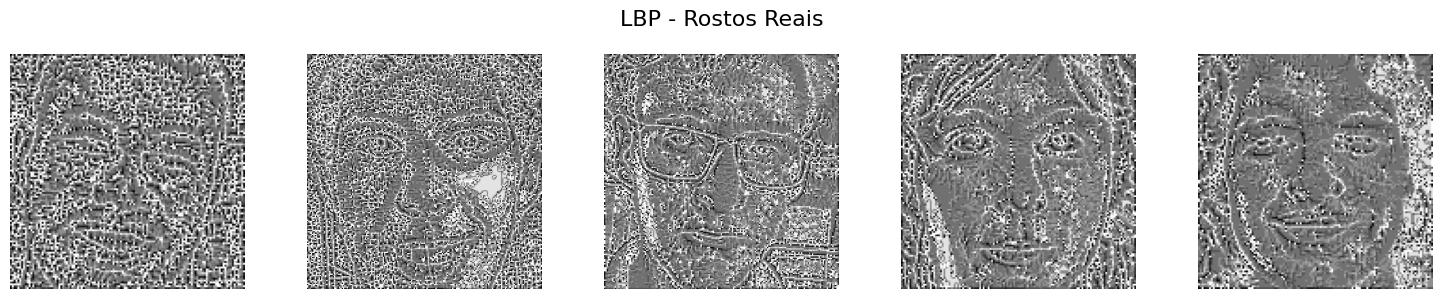

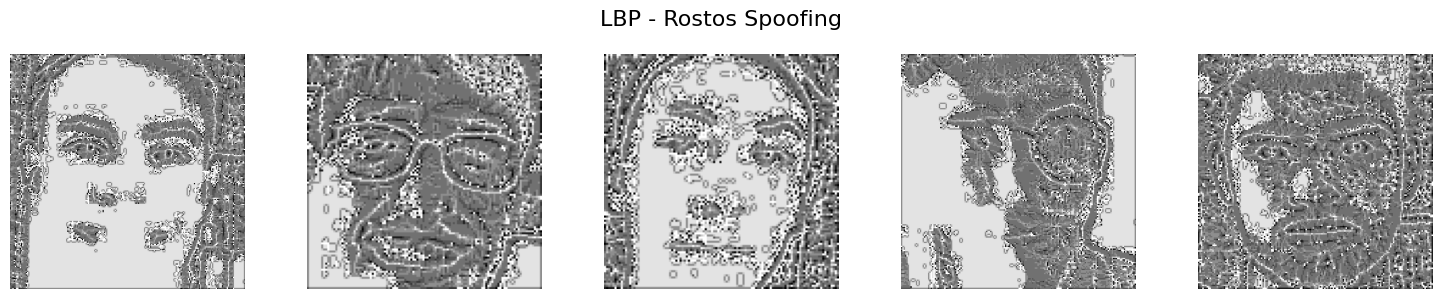

In [36]:
from skimage.feature import local_binary_pattern

# Parâmetros típicos do LBP
P = 8      # número de vizinhos
R = 1      # raio
METHOD = 'uniform'

# Aplica LBP em todas as imagens em tons de cinza
lbp_images = [local_binary_pattern(img, P, R, METHOD) for img in imagens_faces_gray]

def plotar_lbp_exemplos(imagens_lbp, rotulos, rotulo_desejado=1, qtd=5, titulo=''):
    import random
    indices = [i for i, r in enumerate(rotulos) if r == rotulo_desejado]
    indices_selecionados = random.sample(indices, min(qtd, len(indices)))

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices_selecionados):
        plt.subplot(1, qtd, i + 1)
        plt.imshow(imagens_lbp[idx], cmap='gray')
        plt.axis('off')
    plt.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

# Exemplo: visualizar 5 rostos reais com LBP
plotar_lbp_exemplos(lbp_images, rotulos_faces, rotulo_desejado=1, qtd=5, titulo='LBP - Rostos Reais')

# Exemplo: visualizar 5 rostos spoofing com LBP
plotar_lbp_exemplos(lbp_images, rotulos_faces, rotulo_desejado=0, qtd=5, titulo='LBP - Rostos Spoofing')

In [37]:
from skimage.feature import local_binary_pattern

def extrair_lbp_features(lista, bins=10):

    # Calcula histograma normalizado das ocorrências
    n_bins = int(lista.max() + 1)
    hist, _ = np.histogram(lista.ravel(), bins=n_bins, range=(0, n_bins), density=True)

    # Normaliza o tamanho do vetor (pode fazer padding/corte para bins fixos, se quiser)
    if len(hist) < bins:
        hist = np.pad(hist, (0, bins - len(hist)), mode='constant')
    else:
        hist = hist[:bins]

    return hist

Extraindo features

In [38]:
lbp_features = np.array([extrair_lbp_features(img) for img in lbp_images])

In [39]:
np.shape(lbp_features)

(698, 10)

### Separar em treino e teste

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    lbp_features, rotulos_faces, 
    test_size=0.2, 
    stratify=rotulos_faces, 
    random_state=42
)


print(f'Treino: {len(X_train)}, Teste: {len(X_test)}')


Treino: 558, Teste: 140


# LBP - Regressão Logística

Treinando com parâmetros padrões

In [41]:
model = LogisticRegression(max_iter=1000, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

print("Acurácias Balanceadas para cada fold:", cv_scores)

Acurácias Balanceadas para cada fold: [0.93269231 0.89423077 0.93269231 0.94117647 0.88235294]


In [42]:
print(f'Acurácia balanceada média: {100*cv_scores.mean()}%')

Acurácia balanceada média: 91.6628959276018%


Treinando o modelo

In [43]:
from sklearn.preprocessing import StandardScaler

# Criar pipeline com normalização + modelo
preprocess_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)
param_grid = {
    'logisticregression__C': 10.0**np.arange(-2, 3.01, 1),  # Parâmetro de regularização
    'logisticregression__solver': ['liblinear', 'lbfgs'],  # Algoritmos de otimização
    'logisticregression__max_iter': [100, 500, 1000],  # Número de iterações
}

# Instanciando o GridSearchCV
grid_search = GridSearchCV(estimator=preprocess_pipeline, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='balanced_accuracy')

Otimizando hiperparâmetros

In [44]:
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = results[[
    'param_logisticregression__C',
    'param_logisticregression__solver',
    'param_logisticregression__max_iter',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

tabela_resultados.columns = ['C', 'Solver', 'Max Iter', 'Balanced Accuracy', 'Rank']

display(tabela_resultados.head(8))

,C,Solver,Max Iter,Balanced Accuracy,Rank
26,100.0,liblinear,500,0.974027,1
24,100.0,liblinear,100,0.974027,1
25,100.0,lbfgs,100,0.974027,1
27,100.0,lbfgs,500,0.974027,1
28,100.0,liblinear,1000,0.974027,1
29,100.0,lbfgs,1000,0.974027,1
35,1000.0,lbfgs,1000,0.972360,7
31,1000.0,lbfgs,100,0.972360,7


# LBP - SVM

In [45]:
from sklearn.svm import SVC
model = SVC(kernel='rbf')  # Kernel RBF já fixado
preprocess_pipeline = make_pipeline(StandardScaler(),
 model)

param_grid = {
    'svc__C': 10.0**np.arange(-0.5, 1, 0.25),  
    'svc__gamma': 10.0**np.arange(-1, 0, 0.2),  
    'svc__max_iter': [1000, 1500, 2000]  
}

grid_search = GridSearchCV(estimator=preprocess_pipeline, 
                           param_grid=param_grid,
                           cv=5, 
                           n_jobs=-1,
                           scoring='balanced_accuracy')

Treinando com parâmetros padrões

In [46]:
from sklearn.model_selection import cross_val_score
model = preprocess_pipeline
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

print("Acurácias Balanceadas para cada fold:", cv_scores)

Acurácias Balanceadas para cada fold: [0.97115385 0.95192308 0.9724359  0.99019608 0.96666667]


In [47]:
print(f'Acurácia balanceada média: {100*cv_scores.mean()}%')

Acurácia balanceada média: 97.0475113122172%


Otimizando hiperparâmetros

In [48]:
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = results[[
    'param_svc__C',
    'param_svc__gamma',
    'param_svc__max_iter',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

tabela_resultados.columns = ['C', 'Gamma', 'Max Iter', 'Balanced Accuracy', 'Rank']

tabela_resultados['Balanced Accuracy'] = tabela_resultados['Balanced Accuracy'].round(4)

display(tabela_resultados.head(8))

,C,Gamma,Max Iter,Balanced Accuracy,Rank
89,5.623413,0.630957,2000,0.9837,1
87,5.623413,0.630957,1000,0.9837,1
88,5.623413,0.630957,1500,0.9837,1
86,5.623413,0.398107,2000,0.9834,4
85,5.623413,0.398107,1500,0.9834,4
84,5.623413,0.398107,1000,0.9834,4
74,3.162278,0.630957,2000,0.9820,7
73,3.162278,0.630957,1500,0.9820,7


# LBP - RandomForest

In [49]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=0)  
preprocess_pipeline = make_pipeline(StandardScaler(),
 model)
param_grid = {#treinei diversas vezes com multiplos hiperparâmetros, e fui pegando os melhores, por isso estou treinando as vezes com uma opção apenas para ganhar tempo
    'randomforestclassifier__n_estimators': [100, 200],    # número de árvores
    'randomforestclassifier__max_depth': [400, 1000],  # profundidade
    'randomforestclassifier__min_samples_split': [5, 10],  # split mínimo
    'randomforestclassifier__min_samples_leaf': [1,2],
    'randomforestclassifier__bootstrap': [True]
}
grid_search = GridSearchCV(preprocess_pipeline, param_grid, cv=5, n_jobs=-1, scoring='balanced_accuracy')

Treinando com valores padrão

In [50]:
from sklearn.model_selection import cross_val_score
model = preprocess_pipeline
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

print("Acurácias Balanceadas para cada fold:", cv_scores)

Acurácias Balanceadas para cada fold: [0.98076923 0.99038462 0.9724359  0.99019608 0.97352941]


In [51]:
print(f'Acurácia balanceada média: {100*cv_scores.mean()}%')

Acurácia balanceada média: 98.14630467571645%


Otimizando hiperparâmetros

In [52]:
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = results[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'param_randomforestclassifier__min_samples_split',
    'param_randomforestclassifier__min_samples_leaf',
    'param_randomforestclassifier__bootstrap',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

tabela_resultados.columns = ['randomforestclassifier__n_estimators', 'randomforestclassifier__max_depth', 'randomforestclassifier__min_samples_split', 'randomforestclassifier__min_samples_leaf','randomforestclassifier__bootstrap','Balanced Accuracy', 'Rank']

tabela_resultados['Balanced Accuracy'] = tabela_resultados['Balanced Accuracy'].round(4)

display(tabela_resultados.head(8))

,randomforestclassifier__n_estimators,randomforestclassifier__max_depth,randomforestclassifier__min_samples_split,randomforestclassifier__min_samples_leaf,randomforestclassifier__bootstrap,Balanced Accuracy,Rank
0,100,400,5,1,True,0.9834,1
1,200,400,5,1,True,0.9834,1
4,100,400,5,2,True,0.9834,1
5,200,400,5,2,True,0.9834,1
6,100,400,10,2,True,0.9834,1
7,200,400,10,2,True,0.9834,1
8,100,1000,5,1,True,0.9834,1
9,200,1000,5,1,True,0.9834,1


# LBP - Gradient Boosting

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=0)  
preprocess_pipeline = make_pipeline(StandardScaler(),
 model)
param_grid = {
    'gradientboostingclassifier__n_estimators': [200, 300],  # Número de árvores
    'gradientboostingclassifier__learning_rate': [0.7, 1, 1.2],  # Taxa de aprendizado
    'gradientboostingclassifier__max_depth': [2, 3, 5],  # Profundidade das árvores
}

grid_search = GridSearchCV(estimator=preprocess_pipeline, 
                           param_grid=param_grid,
                           cv=5, 
                           n_jobs=-1, 
                           scoring='balanced_accuracy')

Treinando com parâmetros padrão

In [54]:
from sklearn.model_selection import cross_val_score
model = preprocess_pipeline
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

print("Acurácias Balanceadas para cada fold:", cv_scores)

Acurácias Balanceadas para cada fold: [0.9724359  0.98076923 0.98205128 0.99019608 0.96666667]


In [55]:
print(f'Acurácia balanceada média: {100*cv_scores.mean()}%')

Acurácia balanceada média: 97.84238310708899%


In [56]:
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = results[[
    'param_gradientboostingclassifier__n_estimators',
    'param_gradientboostingclassifier__learning_rate',
    'param_gradientboostingclassifier__max_depth',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

tabela_resultados.columns = ['gradientboostingclassifier__n_estimators', 'gradientboostingclassifier__learning_rate', 'gradientboostingclassifier__max_depth', 'Balanced Accuracy', 'Rank']

tabela_resultados['Balanced Accuracy'] = tabela_resultados['Balanced Accuracy'].round(4)

display(tabela_resultados.head(8))

,gradientboostingclassifier__n_estimators,gradientboostingclassifier__learning_rate,gradientboostingclassifier__max_depth,Balanced Accuracy,Rank
8,200,1,3,0.9856,1
9,300,1,3,0.9856,1
7,300,1,2,0.9815,3
6,200,1,2,0.9815,3
0,200,0.7,2,0.9815,3
3,300,0.7,3,0.9815,3
2,200,0.7,3,0.9815,3
1,300,0.7,2,0.9815,3


# Conjunto de teste: melhor resultado foi o Gradient Boosting

In [57]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline com Gradient Boosting e StandardScaler
model = make_pipeline(
    StandardScaler(),
    GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=1,
        max_depth=3,
        random_state=0
    )
)

# Treinamento
model.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(learning_rate=1, n_estimators=200,
                                            random_state=0))])

In [58]:
y_train_pred = model.predict(X_train)
train_balanced_acc = balanced_accuracy_score(y_train, y_train_pred)

# Prediz no conjunto de teste
y_test_pred = model.predict(X_test)
test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

# Exibe os resultados
print(f"Acurácia balanceada no conjunto de treino: {train_balanced_acc:.4f}")
print(f"Acurácia balanceada no conjunto de teste: {test_balanced_acc:.4f}")

Acurácia balanceada no conjunto de treino: 1.0000
Acurácia balanceada no conjunto de teste: 0.9846


### Salvar o melhor modelo para utilizar no sistema

In [59]:
import pickle

# Salvar o modelo
with open('modelo_gradient_boosting.pkl', 'wb') as f:
    pickle.dump(model, f)

# Conclusão

É perceptível que o LBP é um método melhor para detectar fraudes do que o laplaciano, tendo os dois um ótimo desempenho na métrica de acurácia balanceada. Claro que poderíamos fazer um dataset mais robusto utilizando outros celulares para dar mais diversidade ao modelo, ou até levar fotografias, essas são algumas ideias de melhoria para o projeto.